# Step 5: Switch to mixed boundary conditions

Surface salinity restoring ties the surface salinity to observations, which damps the salt-advection feedback. In this notebook I replace the salinity restoring with a fixed freshwater flux that does the same job on average, while keeping temperature restoring. This is called "mixed boundary conditions". Then I check whether the model stays close to its spun-up state without the restoring.

Part A builds the new forcing from the spin-up. Part B analyses a 500-year control run with mixed boundary conditions (`mixed_control`), which also serves as the control for step 6.

I load the libraries and the shared functions, and set the paths and constants.

In [1]:
%matplotlib inline

import os
import sys
import glob

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from MITgcmutils import rdmds

sys.path.append("../src")   # amoc_tools.py lives in the project's src/ folder
from amoc_tools import (read_grid, amoc_series, output_iterations, annual_field,
                        STEPS_PER_YEAR, SV, RHO_FRESH)

RUNS = os.path.expanduser("~/mitgcm_runs/hosing")
SPINUP = os.path.join(RUNS, "spinup")
ORIGINAL_EMP = os.path.expanduser(
    "~/models/MITgcm/verification/tutorial_global_oce_latlon/input/ncep_emp.bin")
OUT_DIR = "../experiments/mixed_forcing"     # emp_mixed.bin and the mixed-BC hosing files
FIG_DIR = "../figures"
DATA_DIR = "../data"
SPINUP_END = 720000                          # last step of the spin-up (year 2000)
CLIM_YEARS = 100                             # the SRELAX climatology covers the last 100 spin-up years
HOSING_SV = [0.1, 0.3, 0.5]                  # hosing strengths for step 6
NX, NY, N_MONTHS = 90, 40, 12
SECONDS_PER_YEAR = 360 * 86400.0
os.makedirs(OUT_DIR, exist_ok=True)

## Part A: build the forcing

I read the grid and masks (from notebooks 02 and 03).

In [2]:
grid = read_grid(SPINUP, DATA_DIR)
ocean = grid["ocean"]
area = grid["rac"] * ocean
print("ocean cells:", ocean.sum(), "| hosing-region cells:", grid["region"].sum())

ocean cells: 2315 | hosing-region cells: 87


I read the 12-month climatology of the salinity restoring flux (`SRELAX`, g/m^2/s, positive adds salt) that the spin-up saved for its last 100 years (years 1901-2000). Keeping all 12 months keeps the seasonal cycle of the restoring.

In [3]:
srelax_clim = rdmds(os.path.join(SPINUP, "srelax_clim100"), SPINUP_END)    # shape (12, 40, 90)
print("SRELAX climatology:", srelax_clim.shape)
for month in range(N_MONTHS):
    print(f"  month {month + 1:2d}: global integral {np.sum(srelax_clim[month] * area) / 1e6:+9.1f} t/s")
print(f"  annual mean:  {np.sum(srelax_clim.mean(axis=0) * area) / 1e6:+9.1f} t/s")

SRELAX climatology: (12, 40, 90)
  month  1: global integral  +13106.3 t/s
  month  2: global integral  +12704.4 t/s
  month  3: global integral   +9621.4 t/s
  month  4: global integral  +14481.1 t/s
  month  5: global integral   +5623.1 t/s
  month  6: global integral   -5457.0 t/s
  month  7: global integral  -16600.6 t/s
  month  8: global integral  -11403.9 t/s
  month  9: global integral  -34169.7 t/s
  month 10: global integral    +836.0 t/s
  month 11: global integral   -1184.1 t/s
  month 12: global integral   +6207.3 t/s
  annual mean:     -519.6 t/s


To turn a salt flux into a freshwater flux I need the surface salinity, because the model converts EmPmR to salt using the local surface salinity (`convertFW2Salt = -1`). I use the model's own surface salinity averaged over the same 100 years. The annual output does not resolve the seasonal cycle of salinity, which is small at the surface compared with its mean.

In [4]:
its = output_iterations(SPINUP, "surf_ts_annual")
its = [it for it in its if it > SPINUP_END - CLIM_YEARS * STEPS_PER_YEAR]
sss_mean = np.zeros((NY, NX))
for it in its:
    sss_mean += annual_field(SPINUP, "surf_ts_annual", "SALT", it) / len(its)
print(f"averaged {len(its)} annual means; surface salinity over ocean {sss_mean[ocean].min():.2f} to {sss_mean[ocean].max():.2f} g/kg")

averaged 100 annual means; surface salinity over ocean 29.82 to 37.44 g/kg


Now the conversion. A virtual salt flux is EmPmR (kg/m^2/s) times salinity (g/kg). So a restoring salt flux F_s gives the same salinity change as an extra EmPmR of F_s / S in kg/m^2/s, or F_s / (1000 x S) in m/s, the unit of the forcing file. A positive F_s (restoring adds salt) becomes a positive EmPmR (more evaporation). The sign is the same.

In [5]:
emp_equivalent = np.zeros((N_MONTHS, NY, NX))     # m/s
for month in range(N_MONTHS):
    emp_equivalent[month][ocean] = srelax_clim[month][ocean] / (RHO_FRESH * sss_mean[ocean])
print(f"equivalent EmPmR range: {emp_equivalent[:, ocean].min():.3e} to {emp_equivalent[:, ocean].max():.3e} m/s")
annual = emp_equivalent.mean(axis=0)
net = np.sum(annual * area) / SV
print(f"annual-mean global integral: {net:+.4f} Sv (positive = net evaporation, i.e. salt added)")
print(f"annual-mean integral over the hosing region: {np.sum(annual * area * grid['region']) / SV:+.4f} Sv")

equivalent EmPmR range: -2.457e-07 to 3.349e-07 m/s
annual-mean global integral: +0.0160 Sv (positive = net evaporation, i.e. salt added)
annual-mean integral over the hosing region: -0.0993 Sv


This map shows the annual-mean freshwater flux that replaces the salinity restoring, in metres of water per year. Red means the restoring was adding salt there (the model surface was too fresh), blue means it was removing salt.

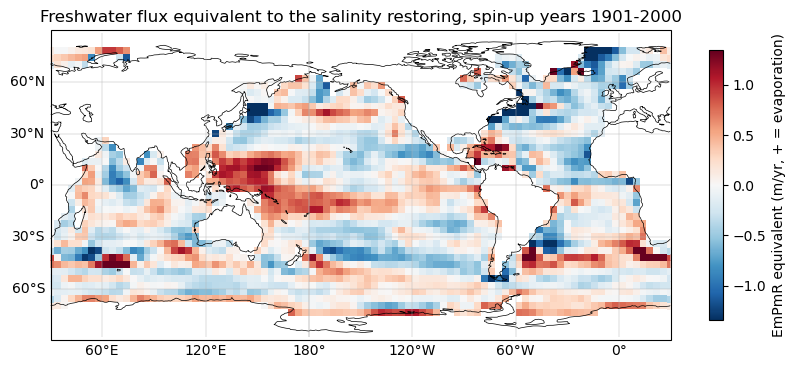

In [6]:
lon_edges = np.arange(0, 361, 4.0)
lat_edges = np.arange(-80, 81, 4.0)
plot_field = np.where(ocean, annual * SECONDS_PER_YEAR, np.nan)    # m per year
limit = np.nanpercentile(np.abs(plot_field), 98)
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-150))
mesh = ax.pcolormesh(lon_edges, lat_edges, plot_field, cmap="RdBu_r", vmin=-limit, vmax=limit,
                     transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(mesh, ax=ax, shrink=0.7, label="EmPmR equivalent (m/yr, + = evaporation)")
ax.set_title("Freshwater flux equivalent to the salinity restoring, spin-up years 1901-2000")
fig.savefig(os.path.join(FIG_DIR, "05_restoring_equivalent_flux.png"), dpi=150, bbox_inches="tight")
plt.show()

I add this flux to the original EmPmR, month by month, and write `emp_mixed.bin` in the same format as the original (12 records of single-precision big-endian numbers).

In [7]:
original = np.fromfile(ORIGINAL_EMP, dtype=">f4").reshape(N_MONTHS, NY, NX)
emp_mixed = original.astype(float) + emp_equivalent
emp_mixed.astype(">f4").tofile(os.path.join(OUT_DIR, "emp_mixed.bin"))
check = np.fromfile(os.path.join(OUT_DIR, "emp_mixed.bin"), dtype=">f4").reshape(N_MONTHS, NY, NX)
added = check.astype(float) - original.astype(float)
print("file size:", os.path.getsize(os.path.join(OUT_DIR, "emp_mixed.bin")), "bytes (original 172800)")
print(f"added flux read back from disk, annual mean global integral: {np.sum(added.mean(axis=0) * area) / SV:+.4f} Sv")
print(f"largest difference from the intended field: {np.max(np.abs(added - emp_equivalent)):.2e} m/s")

file size: 172800 bytes (original 172800)
added flux read back from disk, annual mean global integral: +0.0160 Sv
largest difference from the intended field: 9.38e-15 m/s


For step 6 I also need hosing files with mixed boundary conditions: `emp_mixed.bin` plus the same hosing anomaly as in step 3 (spread evenly over the hosing region). I build them here, so step 6 only has to run the model, and check their totals the same way.

In [8]:
region = grid["region"]
region_area = np.sum(grid["rac"][region])
for strength in HOSING_SV:
    anomaly = np.zeros((NY, NX))
    anomaly[region] = -strength * SV / region_area        # negative EmPmR = freshwater into the ocean
    field = np.zeros((N_MONTHS, NY, NX))
    for month in range(N_MONTHS):
        field[month] = emp_mixed[month] + anomaly
    name = f"emp_hose{int(round(strength * 100)):03d}.bin"
    field.astype(">f4").tofile(os.path.join(OUT_DIR, name))
    back = np.fromfile(os.path.join(OUT_DIR, name), dtype=">f4").reshape(N_MONTHS, NY, NX).astype(float)
    totals = [-np.sum((back[m] - check[m].astype(float)) * area) / SV for m in range(N_MONTHS)]
    print(f"{name}: hosing relative to emp_mixed.bin, min {min(totals):.8f} Sv, max {max(totals):.8f} Sv")

emp_hose010.bin: hosing relative to emp_mixed.bin, min 0.10000000 Sv, max 0.10000000 Sv
emp_hose030.bin: hosing relative to emp_mixed.bin, min 0.30000000 Sv, max 0.30000000 Sv
emp_hose050.bin: hosing relative to emp_mixed.bin, min 0.50000000 Sv, max 0.50000000 Sv


## Part B: the mixed-boundary-condition control

The run `mixed_control` starts from the same spin-up pickup (year 2000) as the restoring runs, with `tauSaltClimRelax = 0` (salinity restoring off), `EmPmRFile = 'emp_mixed.bin'`, and temperature restoring unchanged. It ran for 500 years (2001-2500). First I check that it ended normally and that the salinity restoring flux really is zero.

In [9]:
MIXED = os.path.join(RUNS, "mixed_control")
RESTORE = os.path.join(RUNS, "restore_control")
print("ended normally:", "Execution ended Normally" in open(os.path.join(MIXED, "output.txt")).read())
its_mixed = output_iterations(MIXED, "surf_flux_annual")
largest = 0.0
for it in its_mixed:
    largest = max(largest, np.max(np.abs(annual_field(MIXED, "surf_flux_annual", "SRELAX", it))))
print(f"annual means: {len(its_mixed)} | largest |SRELAX| in any year: {largest:.2e} g/m^2/s")

ended normally: True


annual means: 500 | largest |SRELAX| in any year: 0.00e+00 g/m^2/s


I compute the AMOC index for the mixed control and compare it with the restoring control and the end of the spin-up.

In [10]:
years_spin, amoc_spin = amoc_series([SPINUP], grid)
keep = years_spin > years_spin[-1] - 100
years, amoc_mixed = amoc_series([MIXED], grid)
years_r, amoc_restore = amoc_series([RESTORE], grid)
assert np.array_equal(years, years_r)

csv_path = os.path.join(DATA_DIR, "amoc_index_mixed_control.csv")
with open(csv_path, "w") as f:
    f.write("model_year,mixed_control_sv,restore_control_sv\n")
    for n in range(len(years)):
        f.write(f"{years[n]:.0f},{amoc_mixed[n]:.4f},{amoc_restore[n]:.4f}\n")
print("saved", csv_path)

def trend_per_century(x, y, last_years):
    keep_t = x >= x[-1] - last_years
    return np.polyfit(x[keep_t], y[keep_t], 1)[0] * 100.0

for label, series in [("restoring control", amoc_restore), ("mixed control", amoc_mixed)]:
    print(f"{label:18s}: year 2001 {series[0]:.2f} Sv | mean 2491-2500 {series[-10:].mean():.2f} Sv | "
          f"min {series.min():.2f} Sv | max {series.max():.2f} Sv | trend over the last 300 years "
          f"{trend_per_century(years, series, 300):+.3f} Sv per century")
print(f"difference at 2491-2500 (mixed - restoring): {amoc_mixed[-10:].mean() - amoc_restore[-10:].mean():+.2f} Sv")

saved ../data/amoc_index_mixed_control.csv
restoring control : year 2001 19.82 Sv | mean 2491-2500 19.94 Sv | min 19.82 Sv | max 19.95 Sv | trend over the last 300 years +0.025 Sv per century
mixed control     : year 2001 19.78 Sv | mean 2491-2500 19.74 Sv | min 16.51 Sv | max 19.84 Sv | trend over the last 300 years -0.023 Sv per century
difference at 2491-2500 (mixed - restoring): -0.21 Sv


This figure compares the AMOC in the two controls.

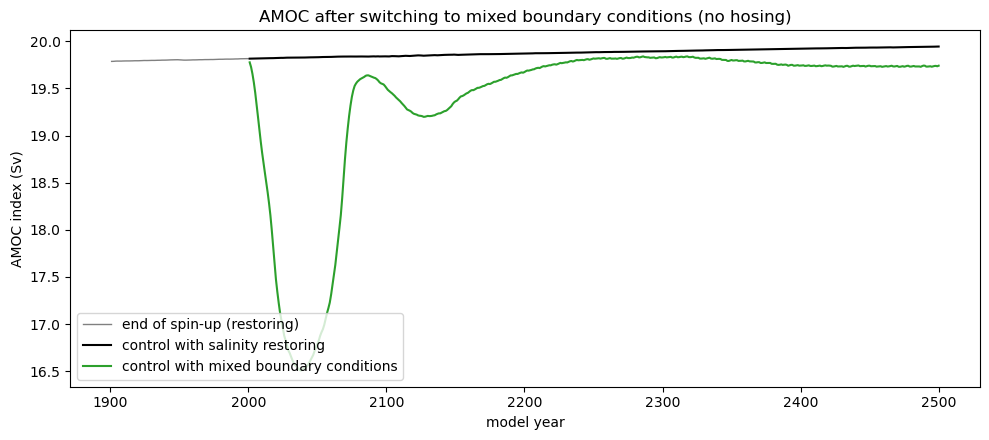

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years_spin[keep], amoc_spin[keep], color="0.5", lw=1, label="end of spin-up (restoring)")
ax.plot(years, amoc_restore, color="k", lw=1.5, label="control with salinity restoring")
ax.plot(years, amoc_mixed, color="tab:green", lw=1.5, label="control with mixed boundary conditions")
ax.set_xlabel("model year")
ax.set_ylabel("AMOC index (Sv)")
ax.set_title("AMOC after switching to mixed boundary conditions (no hosing)")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_amoc_mixed_control.png"), dpi=150)
plt.show()

Without restoring, nothing holds the surface salinity near observations any more. I compare the two controls' mean surface salinity in the hosing region and in the whole Atlantic, and the global volume-mean salinity, to see whether the mixed control drifts.

In [12]:
def region_mean(field, mask):
    return np.sum(field * grid["rac"] * mask) / np.sum(grid["rac"] * mask)

its_r = output_iterations(RESTORE, "surf_ts_annual")
sss_region = {"mixed": [], "restore": []}
sss_atlantic = {"mixed": [], "restore": []}
for it in its_r:
    for label, run in [("mixed", MIXED), ("restore", RESTORE)]:
        s = annual_field(run, "surf_ts_annual", "SALT", it)
        sss_region[label].append(region_mean(s, grid["region"]))
        sss_atlantic[label].append(region_mean(s, grid["atlantic"]))
for label in sss_region:
    sss_region[label] = np.array(sss_region[label])
    sss_atlantic[label] = np.array(sss_atlantic[label])

def read_global_mean(run, field):
    path = glob.glob(os.path.join(run, "ts_global_stats.*.txt"))[0]
    values = []
    current = None
    for line in open(path):
        if line.startswith(" field :"):
            current = line.split()[2]
        elif current == field and line.strip().startswith("0 "):
            values.append(float(line.split()[1]))
    return np.array(values)

glob_mixed = read_global_mean(MIXED, "SALT")
glob_restore = read_global_mean(RESTORE, "SALT")
for name, a, b in [("hosing-region surface salinity", sss_region["mixed"], sss_region["restore"]),
                   ("Atlantic surface salinity", sss_atlantic["mixed"], sss_atlantic["restore"])]:
    print(f"{name}: mixed - restoring = {a[0] - b[0]:+.4f} (2001), {a[-10:].mean() - b[-10:].mean():+.4f} g/kg (2491-2500)")
print(f"global volume-mean salinity at the end: mixed {glob_mixed[-1]:.5f}, restoring {glob_restore[-1]:.5f}, "
      f"difference {glob_mixed[-1] - glob_restore[-1]:+.5f} g/kg")

hosing-region surface salinity: mixed - restoring = -0.0049 (2001), +0.0154 g/kg (2491-2500)
Atlantic surface salinity: mixed - restoring = -0.0012 (2001), +0.0482 g/kg (2491-2500)
global volume-mean salinity at the end: mixed 34.73119, restoring 34.71872, difference +0.01247 g/kg


This map shows where the surface salinity of the mixed control has moved away from the restoring control by the end (mean of 2491-2500).

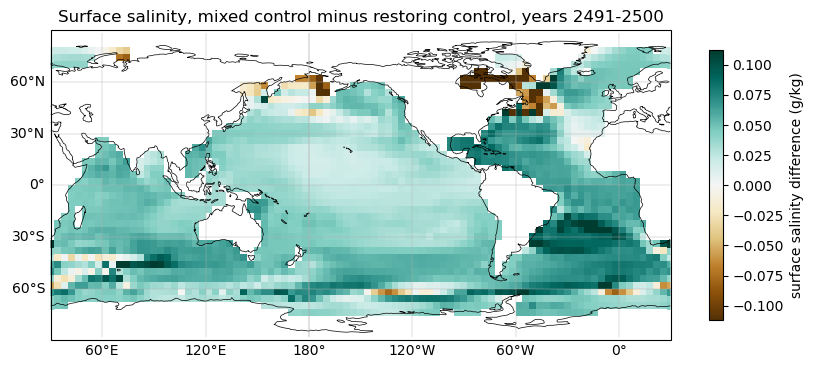

In [13]:
diff = np.zeros((NY, NX))
for it in its_r[-10:]:
    diff += (annual_field(MIXED, "surf_ts_annual", "SALT", it)
             - annual_field(RESTORE, "surf_ts_annual", "SALT", it)) / 10
diff = np.where(ocean, diff, np.nan)
limit = max(np.nanpercentile(np.abs(diff), 98), 0.01)
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-150))
mesh = ax.pcolormesh(lon_edges, lat_edges, diff, cmap="BrBG", vmin=-limit, vmax=limit, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(mesh, ax=ax, shrink=0.7, label="surface salinity difference (g/kg)")
ax.set_title("Surface salinity, mixed control minus restoring control, years 2491-2500")
fig.savefig(os.path.join(FIG_DIR, "05_sss_mixed_minus_restore.png"), dpi=150, bbox_inches="tight")
plt.show()

The mixed control ends up saltier than the restoring control. In step 4 I found that the total salt in this model only responds to the net freshwater the ocean gains or loses. If that is right, I can predict the difference. (The factor 1000/1035 below is explained in step 7: the model turns a freshwater mass flux into volume with rhoConst = 1035 kg/m^3.) The restoring control keeps losing salt through `SRELAX`. The mixed control has no `SRELAX`, but its new forcing contains a small net evaporation, which concentrates the salt. This cell compares the prediction with the measured difference.

In [14]:
RHO_CONST = 1035.0
volume = np.sum(grid["hfacc"] * grid["drf"][:, None, None] * grid["rac"][None, :, :])
seconds = len(its_r) * SECONDS_PER_YEAR
srelax_restore = np.mean([np.sum(annual_field(RESTORE, "surf_flux_annual", "SRELAX", it) * area) for it in its_r])  # g/s
salt_mean = 0.5 * (glob_mixed[-1] + glob_restore[-1])                     # g/kg, mean salinity of the ocean
change_restore = srelax_restore * seconds / (RHO_CONST * volume)          # g/kg, salt removed by restoring
change_mixed = net * SV * (RHO_FRESH / RHO_CONST) * seconds / volume * salt_mean   # g/kg, concentration by net evaporation;
# 1000/1035 because the model turns the freshwater mass flux into volume with rhoConst (found in step 7)
print(f"restoring control, mean SRELAX: {srelax_restore / 1e6:+.1f} t/s -> {change_restore:+.5f} g/kg over {len(its_r)} years")
print(f"mixed control, net evaporation {net:+.4f} Sv -> {change_mixed:+.5f} g/kg over {len(its_r)} years")
print(f"predicted difference (mixed - restoring): {change_mixed - change_restore:+.5f} g/kg")
print(f"measured difference at the end:           {glob_mixed[-1] - glob_restore[-1]:+.5f} g/kg")

restoring control, mean SRELAX: -545.9 t/s -> -0.00620 g/kg over 500 years
mixed control, net evaporation +0.0160 Sv -> +0.00631 g/kg over 500 years
predicted difference (mixed - restoring): +0.01251 g/kg
measured difference at the end:           +0.01247 g/kg
